# 05 — ABP reweighting and the Boltzmann law

This notebook tests the central claim

$
\pi(x)=Z^{-1}\exp[-\beta V(x)]
      =Z^{-1}\exp[-V(x)/D],
\qquad \beta=D^{-1},
$

using trajectories generated by `ABPMetaDynamics`.

## Experimental design

- No transition detector is used: every trajectory has a fixed total length and is not stopped at the first barrier crossing.
- Every potential is simulated from several initial positions and deterministic seeds.
- A burn-in fraction is discarded and the retained trajectory is thinned before histogram construction.
- Every trajectory is normalized separately before trajectories are averaged. This prevents a trajectory-specific additive offset in the adaptive bias from dominating the pooled estimate.
- Histogram bin edges are fixed in advance and shared by every worker, initial condition and replicate.
- Long runs are cached with `save_result`; later notebook executions can reuse them with `load_result`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
import hashlib
import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from stage_escape.abp_abf import (
    ABPMetaDynamics,
    Potential,
    extract_coordinate,
    normalize_histogram_counts,
    theoretical_density_1d,
    weighted_histogram_counts,
)
from stage_escape.result_io import load_result, save_result

# "smoke": quick pipeline check; "full": report-quality runs; "load": full cache only.
RUN_MODE = "full"
REUSE_CACHE = True
N_JOBS = -1
BASE_SEED = 2026

SMOKE_REPLICATES = 1
FULL_REPLICATES = 2
BURN_IN_FRACTION = 0.20
THINNING_STRIDE = 10


def find_repo_root(start: Path | None = None) -> Path:
    """Locate the repository whether Jupyter starts from root or notebooks/."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (
            candidate / "src" / "stage_escape"
        ).exists():
            return candidate
    raise FileNotFoundError(
        "Repository root not found. Start Jupyter inside the STAGE repository."
    )


REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "notebook_05"
CACHE_DIR = ARTIFACT_DIR / "results"
FIGURE_DIR = ARTIFACT_DIR / "figures"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
print(f"Repository root: {REPO_ROOT}")
print(f"Artifacts: {ARTIFACT_DIR}")

Repository root: /home/administrateur/Bureau/STAGE
Artifacts: /home/administrateur/Bureau/STAGE/artifacts/notebook_05


## Potential catalogue

The first quartic double well is the potential used in the historical exponential-law experiment. The scaled quartic double well and the harmonic well are the existing one-dimensional reference potentials used by the refactored repository. Keeping all cases in one registry ensures that the same simulation and analysis pipeline is applied to each potential.

In [2]:
def scalar_coordinate(position: Any) -> float:
    values = np.asarray(position, dtype=float).reshape(-1)
    if values.size != 1:
        raise ValueError(
            f"Expected a one-dimensional position, got shape {values.shape}."
        )
    return float(values[0])


def historical_double_well() -> Potential:
    """V(x) = (1 - x²)², used in the historical notebook experiment."""
    return Potential(
        dimension=1,
        function=lambda p: (1.0 - scalar_coordinate(p) ** 2) ** 2,
        first_derivative=lambda p: np.array(
            [-4.0 * scalar_coordinate(p) * (1.0 - scalar_coordinate(p) ** 2)]
        ),
        second_derivative=lambda p: np.array(
            [[12.0 * scalar_coordinate(p) ** 2 - 4.0]]
        ),
    )


def reference_double_well() -> Potential:
    """V(x) = ¼(x² - 1)², used by the current 1D reference workflow."""
    return Potential(
        dimension=1,
        function=lambda p: 0.25 * (scalar_coordinate(p) ** 2 - 1.0) ** 2,
        first_derivative=lambda p: np.array(
            [scalar_coordinate(p) * (scalar_coordinate(p) ** 2 - 1.0)]
        ),
        second_derivative=lambda p: np.array(
            [[3.0 * scalar_coordinate(p) ** 2 - 1.0]]
        ),
    )


def harmonic_well() -> Potential:
    """V(x) = ½x², used by the current ABP/ABF smoke workflow."""
    return Potential(
        dimension=1,
        function=lambda p: 0.5 * scalar_coordinate(p) ** 2,
        first_derivative=lambda p: np.array([scalar_coordinate(p)]),
        second_derivative=lambda _p: np.array([[1.0]]),
    )


@dataclass(frozen=True)
class PotentialCase:
    key: str
    label: str
    formula: str
    potential: Potential
    domain: tuple[float, float]
    initial_positions: tuple[float, ...]
    diffusion: float
    delta_t: float
    deposition_stride: int
    bias_height: float
    bias_width: float
    bins: int
    smoke_steps: int
    full_steps: int


POTENTIAL_CASES = {
    "historical_double_well": PotentialCase(
        key="historical_double_well",
        label="Historical quartic double well",
        formula="V(x) = (1 - x²)²",
        potential=historical_double_well(),
        domain=(-2.0, 2.0),
        initial_positions=(-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5),
        diffusion=0.20,
        delta_t=1e-3,
        deposition_stride=100,
        bias_height=0.02,
        bias_width=0.15,
        bins=80,
        smoke_steps=5_000,
        full_steps=100_000,
    ),
    "reference_double_well": PotentialCase(
        key="reference_double_well",
        label="Scaled quartic double well",
        formula="V(x) = ¼(x² - 1)²",
        potential=reference_double_well(),
        domain=(-2.25, 2.25),
        initial_positions=(-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5),
        diffusion=0.10,
        delta_t=1e-3,
        deposition_stride=100,
        bias_height=0.01,
        bias_width=0.15,
        bins=90,
        smoke_steps=5_000,
        full_steps=100_000,
    ),
    "harmonic": PotentialCase(
        key="harmonic",
        label="Harmonic well",
        formula="V(x) = ½x²",
        potential=harmonic_well(),
        domain=(-2.5, 2.5),
        initial_positions=(-2.0, -1.0, 0.0, 1.0, 2.0),
        diffusion=0.20,
        delta_t=1e-3,
        deposition_stride=100,
        bias_height=0.02,
        bias_width=0.25,
        bins=80,
        smoke_steps=5_000,
        full_steps=75_000,
    ),
}


def trapezoid(values: np.ndarray, coordinates: np.ndarray) -> float:
    """Integrate compatibly with NumPy 1.26 and 2.x."""
    implementation = getattr(np, "trapezoid", None)
    if implementation is None:
        implementation = np.trapz
    return float(implementation(values, coordinates))


def theoretical_domain_mass(case: PotentialCase, extension_factor: float = 2.0) -> float:
    """Estimate how much Boltzmann mass lies inside the selected domain."""
    left, right = case.domain
    center = 0.5 * (left + right)
    half_width = 0.5 * (right - left)
    extended = (
        center - extension_factor * half_width,
        center + extension_factor * half_width,
    )
    x = np.linspace(*extended, 50_001)
    density = theoretical_density_1d(case.potential, x, case.diffusion)
    inside = (x >= left) & (x <= right)
    return trapezoid(density[inside], x[inside])


def simulation_signature(case: PotentialCase) -> str:
    """Hash every simulation parameter used to make a cache entry."""
    payload = {
        "revision": "3d29c8a",
        "case": case.key,
        "diffusion": case.diffusion,
        "delta_t": case.delta_t,
        "deposition_stride": case.deposition_stride,
        "bias_height": case.bias_height,
        "bias_width": case.bias_width,
    }
    encoded = json.dumps(payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()[:10]

In [3]:
potential_table = pd.DataFrame(
    [
        {
            "key": case.key,
            "potential": case.formula,
            "D": case.diffusion,
            "beta": 1.0 / case.diffusion,
            "domain": case.domain,
            "theory_mass_in_domain": theoretical_domain_mass(case),
            "initial_positions": case.initial_positions,
            "smoke_steps": case.smoke_steps,
            "full_steps": case.full_steps,
            "cache_signature": simulation_signature(case),
        }
        for case in POTENTIAL_CASES.values()
    ]
).set_index("key")
potential_table

,potential,D,beta,domain,theory_mass_in_domain,initial_positions,smoke_steps,full_steps,cache_signature
key,,,,,,,,,
historical_double_well,V(x) = (1 - x²)²,0.2,5.0,"(-2.0, 2.0)",1.0,"(-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5)",5000,100000,d9bfd2479e
reference_double_well,V(x) = ¼(x² - 1)²,0.1,10.0,"(-2.25, 2.25)",1.0,"(-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5)",5000,100000,071436ec01
harmonic,V(x) = ½x²,0.2,5.0,"(-2.5, 2.5)",1.0,"(-2.0, -1.0, 0.0, 1.0, 2.0)",5000,75000,35726d09d3


## Theoretical distributions before simulation

This cell checks the potential definitions and the numerical comparison domain independently of ABP. `theory_mass_in_domain` is estimated after normalizing the same Boltzmann law on a domain twice as wide; values close to one indicate that the selected histogram range does not appreciably truncate the theoretical tails.

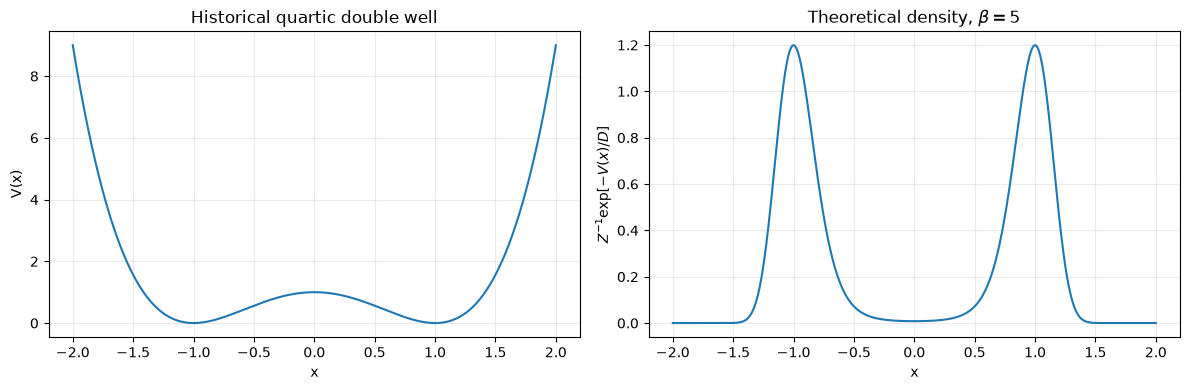

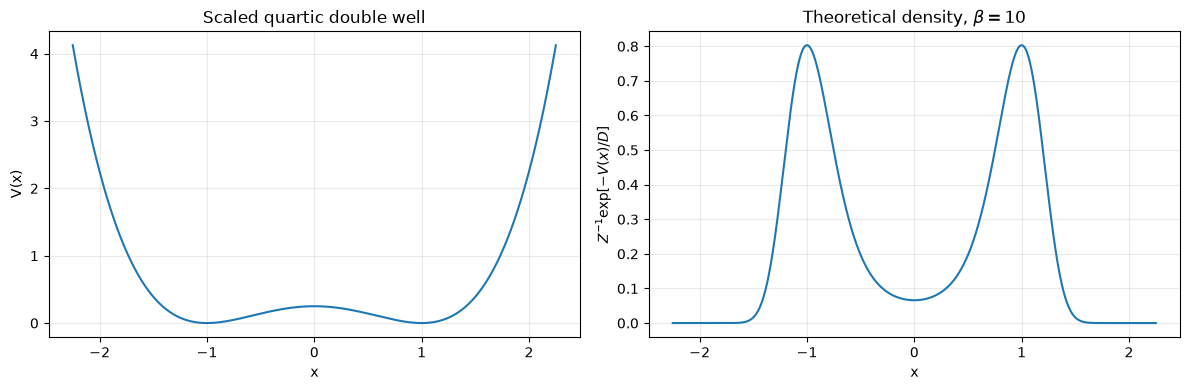

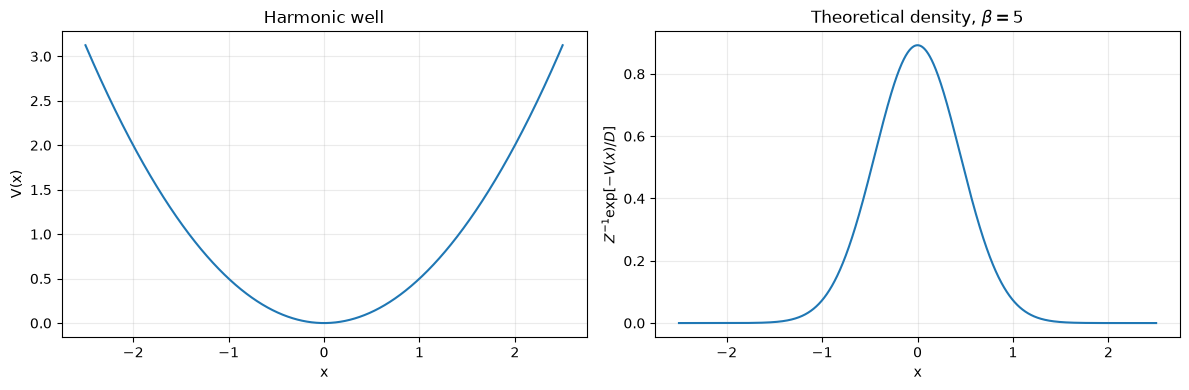

In [4]:
for case in POTENTIAL_CASES.values():
    x = np.linspace(*case.domain, 2_000)
    potential_values = np.array(
        [case.potential.potential_at(np.array([value])) for value in x],
        dtype=float,
    )
    density = theoretical_density_1d(case.potential, x, case.diffusion)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(x, potential_values)
    axes[0].set(title=case.label, xlabel="x", ylabel="V(x)")
    axes[0].grid(alpha=0.25)

    axes[1].plot(x, density)
    axes[1].set(
        title=rf"Theoretical density, $\beta={1.0 / case.diffusion:g}$",
        xlabel="x",
        ylabel=r"$Z^{-1}\exp[-V(x)/D]$",
    )
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    plt.show()

## Reproducible ABP runs

`max_steps` is the total number of integration steps. The detector is deliberately `None`; otherwise a double-well trajectory could stop at its first transition and could not represent an equilibrium position distribution.

In [5]:
def safe_float_token(value: float) -> str:
    return (
        f"{value:+.3f}"
        .replace("+", "p")
        .replace("-", "m")
        .replace(".", "d")
    )


def result_stem(
    case: PotentialCase,
    initial_position: float,
    replicate: int,
    max_steps: int,
) -> Path:
    return CACHE_DIR / (
        f"{case.key}__cfg_{simulation_signature(case)}"
        f"__x0_{safe_float_token(initial_position)}"
        f"__rep_{replicate:02d}__steps_{max_steps}"
    )


def cached_result_exists(stem: Path) -> bool:
    return stem.with_suffix(".json").exists() and stem.with_suffix(".npz").exists()


def validate_cached_result(result, case: PotentialCase, seed: int, max_steps: int) -> None:
    checks = {
        "diffusion": np.isclose(result.diffusion, case.diffusion),
        "delta_t": np.isclose(result.delta_t, case.delta_t),
        "seed": result.seed == seed,
        "n_steps": result.n_steps == max_steps,
        "bias_height": np.isclose(result.bias_height, case.bias_height),
        "bias_width": np.isclose(result.bias_width, case.bias_width),
    }
    failed = [name for name, passed in checks.items() if not passed]
    if failed:
        raise ValueError(
            "Cached ABP result is incompatible with the requested run: "
            + ", ".join(failed)
        )


def run_one_trajectory(
    case_key: str,
    initial_position: float,
    replicate: int,
    max_steps: int,
):
    case = POTENTIAL_CASES[case_key]
    case_index = list(POTENTIAL_CASES).index(case_key)
    start_index = case.initial_positions.index(initial_position)
    seed = BASE_SEED + 10_000 * case_index + 100 * replicate + start_index
    stem = result_stem(case, initial_position, replicate, max_steps)

    if REUSE_CACHE and cached_result_exists(stem):
        result = load_result(stem)
        validate_cached_result(result, case, seed, max_steps)
        source = "cache"
    elif RUN_MODE == "load":
        raise FileNotFoundError(f"Missing cached result: {stem}")
    else:
        simulation = ABPMetaDynamics(
            deposition_stride=case.deposition_stride,
            transition_detector=None,
            delta_t=case.delta_t,
            dimension=1,
            D=case.diffusion,
            initial_position=np.array([initial_position]),
            b=case.potential,
            W=case.bias_height,
            sigma=case.bias_width,
            seed=seed,
        )
        result = simulation.run(max_steps=max_steps)
        validate_cached_result(result, case, seed, max_steps)
        save_result(result, stem)
        source = "simulation"

    return {
        "case_key": case_key,
        "initial_position": initial_position,
        "replicate": replicate,
        "seed": seed,
        "max_steps": max_steps,
        "source": source,
        "result": result,
    }


def build_jobs() -> list[tuple[str, float, int, int]]:
    if RUN_MODE not in {"smoke", "full", "load"}:
        raise ValueError("RUN_MODE must be 'smoke', 'full' or 'load'.")

    is_smoke = RUN_MODE == "smoke"
    replicates = SMOKE_REPLICATES if is_smoke else FULL_REPLICATES
    jobs = []
    for case in POTENTIAL_CASES.values():
        max_steps = case.smoke_steps if is_smoke else case.full_steps
        for initial_position in case.initial_positions:
            for replicate in range(replicates):
                jobs.append((case.key, initial_position, replicate, max_steps))
    return jobs

In [6]:
jobs = build_jobs()
print(f"Running/loading {len(jobs)} trajectories in {RUN_MODE!r} mode.")

if N_JOBS == 1:
    runs = [run_one_trajectory(*job) for job in jobs]
else:
    runs = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(run_one_trajectory)(*job) for job in jobs
    )

run_inventory = pd.DataFrame(
    [
        {
            "case": run["case_key"],
            "x0": run["initial_position"],
            "replicate": run["replicate"],
            "seed": run["seed"],
            "steps": run["result"].n_steps,
            "termination": run["result"].termination_reason,
            "source": run["source"],
        }
        for run in runs
    ]
)
run_inventory

Running/loading 38 trajectories in 'full' mode.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  31 out of  38 | elapsed:  8.8min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  38 out of  38 | elapsed:  9.6min finished


,case,x0,replicate,seed,steps,termination,source
0,historical_double_well,-1.5,0,2026,100000,max_steps,simulation
1,historical_double_well,-1.5,1,2126,100000,max_steps,simulation
2,historical_double_well,-1.0,0,2027,100000,max_steps,simulation
3,historical_double_well,-1.0,1,2127,100000,max_steps,simulation
4,historical_double_well,-0.5,0,2028,100000,max_steps,simulation
5,historical_double_well,-0.5,1,2128,100000,max_steps,simulation
6,historical_double_well,0.0,0,2029,100000,max_steps,simulation
7,historical_double_well,0.0,1,2129,100000,max_steps,simulation
8,historical_double_well,0.5,0,2030,100000,max_steps,simulation
9,historical_double_well,0.5,1,2130,100000,max_steps,simulation


## Distribution analysis

The comparison is performed on probability **mass per common bin**. This avoids ambiguities caused by bin widths and makes the discrepancy metrics directly interpretable.

For each trajectory:

- the raw and weighted bin masses are normalized independently;
- the effective sample size is computed from the retained weights;
- the first and second halves of the retained trajectory are compared to diagnose late-time stability;
- the fraction of samples outside the fixed domain is recorded.

The case-level empirical distribution is the arithmetic mean of the trajectory-level distributions. Thus every initial condition and replicate has the same influence.

In [7]:
def normalized_mass(counts: np.ndarray) -> np.ndarray:
    counts = np.asarray(counts, dtype=float)
    total = float(np.sum(counts))
    if not np.isfinite(total) or total <= 0.0:
        raise ValueError(
            "Histogram has no finite positive mass in the selected domain."
        )
    return counts / total


def theoretical_bin_mass(case: PotentialCase, edges: np.ndarray) -> np.ndarray:
    x_fine = np.linspace(
        edges[0],
        edges[-1],
        max(20_001, 250 * case.bins + 1),
    )
    density = theoretical_density_1d(case.potential, x_fine, case.diffusion)

    increments = 0.5 * (density[:-1] + density[1:]) * np.diff(x_fine)
    cdf = np.concatenate(([0.0], np.cumsum(increments)))
    cdf /= cdf[-1]

    cdf_at_edges = np.interp(edges, x_fine, cdf)
    return normalized_mass(np.diff(cdf_at_edges))


def effective_sample_size(weights: np.ndarray) -> float:
    weights = np.asarray(weights, dtype=float)
    numerator = float(np.sum(weights)) ** 2
    denominator = float(np.sum(weights**2))
    return 0.0 if denominator <= 0.0 else numerator / denominator


def distribution_metrics(
    empirical: np.ndarray,
    theoretical: np.ndarray,
) -> dict[str, float]:
    p = normalized_mass(empirical)
    q = normalized_mass(theoretical)
    eps = np.finfo(float).eps
    midpoint = 0.5 * (p + q)

    tv = 0.5 * np.sum(np.abs(p - q))
    hellinger = np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))
    js = 0.5 * np.sum(p * np.log((p + eps) / (midpoint + eps)))
    js += 0.5 * np.sum(q * np.log((q + eps) / (midpoint + eps)))
    cdf_sup = np.max(np.abs(np.cumsum(p) - np.cumsum(q)))

    return {
        "tv": float(tv),
        "hellinger": float(hellinger),
        "js": float(js),
        "cdf_sup": float(cdf_sup),
    }


def trajectory_histograms(
    run: dict[str, Any],
    case: PotentialCase,
    edges: np.ndarray,
) -> dict[str, Any]:
    result = run["result"]
    positions = extract_coordinate(result.positions, axis=0)
    weights = np.asarray(result.weights, dtype=float)
    if positions.shape != weights.shape:
        raise ValueError("ABP positions and weights must have the same length.")

    burn_in = int(BURN_IN_FRACTION * len(positions))
    retained_positions = positions[burn_in::THINNING_STRIDE]
    retained_weights = weights[burn_in::THINNING_STRIDE]
    if retained_positions.size < 4:
        raise ValueError("Too few samples remain after burn-in and thinning.")

    raw_counts, returned_edges = weighted_histogram_counts(
        retained_positions,
        bins=edges,
    )
    weighted_counts, weighted_edges = weighted_histogram_counts(
        retained_positions,
        weights=retained_weights,
        bins=edges,
    )
    if not np.array_equal(returned_edges, edges) or not np.array_equal(
        weighted_edges, edges
    ):
        raise RuntimeError("Histogram helper changed the requested bin edges.")

    midpoint = retained_positions.size // 2
    first_counts, _ = weighted_histogram_counts(
        retained_positions[:midpoint],
        weights=retained_weights[:midpoint],
        bins=edges,
    )
    second_counts, _ = weighted_histogram_counts(
        retained_positions[midpoint:],
        weights=retained_weights[midpoint:],
        bins=edges,
    )

    inside = (retained_positions >= edges[0]) & (retained_positions <= edges[-1])
    window_tv = distribution_metrics(first_counts, second_counts)["tv"]
    ess = effective_sample_size(retained_weights)

    return {
        "case_key": run["case_key"],
        "initial_position": run["initial_position"],
        "replicate": run["replicate"],
        "raw_mass": normalized_mass(raw_counts),
        "weighted_mass": normalized_mass(weighted_counts),
        "ess": ess,
        "ess_fraction": ess / retained_weights.size,
        "outside_fraction": 1.0 - float(np.mean(inside)),
        "window_tv": window_tv,
        "n_retained": retained_positions.size,
    }

In [8]:
case_analyses: dict[str, dict[str, Any]] = {}
trajectory_diagnostics = []
summary_rows = []

for case in POTENTIAL_CASES.values():
    edges = np.linspace(case.domain[0], case.domain[1], case.bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    theory_mass = theoretical_bin_mass(case, edges)

    case_runs = [run for run in runs if run["case_key"] == case.key]
    trajectory_results = [
        trajectory_histograms(run, case, edges) for run in case_runs
    ]
    trajectory_diagnostics.extend(trajectory_results)

    raw_mass = normalized_mass(
        np.mean([item["raw_mass"] for item in trajectory_results], axis=0)
    )
    weighted_mass = normalized_mass(
        np.mean([item["weighted_mass"] for item in trajectory_results], axis=0)
    )

    raw_metrics = distribution_metrics(raw_mass, theory_mass)
    weighted_metrics = distribution_metrics(weighted_mass, theory_mass)

    by_initial_position = {}
    for initial_position in case.initial_positions:
        selected = [
            item for item in trajectory_results
            if item["initial_position"] == initial_position
        ]
        by_initial_position[initial_position] = normalized_mass(
            np.mean([item["weighted_mass"] for item in selected], axis=0)
        )

    case_analyses[case.key] = {
        "case": case,
        "edges": edges,
        "centers": centers,
        "theory_mass": theory_mass,
        "raw_mass": raw_mass,
        "weighted_mass": weighted_mass,
        "by_initial_position": by_initial_position,
    }

    summary_rows.append(
        {
            "case": case.key,
            "raw_tv": raw_metrics["tv"],
            "weighted_tv": weighted_metrics["tv"],
            "raw_hellinger": raw_metrics["hellinger"],
            "weighted_hellinger": weighted_metrics["hellinger"],
            "raw_js": raw_metrics["js"],
            "weighted_js": weighted_metrics["js"],
            "raw_cdf_sup": raw_metrics["cdf_sup"],
            "weighted_cdf_sup": weighted_metrics["cdf_sup"],
            "median_ess_fraction": float(np.median([
                item["ess_fraction"] for item in trajectory_results
            ])),
            "median_window_tv": float(np.median([
                item["window_tv"] for item in trajectory_results
            ])),
            "max_outside_fraction": float(np.max([
                item["outside_fraction"] for item in trajectory_results
            ])),
            "weighted_improves_tv": weighted_metrics["tv"] < raw_metrics["tv"],
            "weighted_improves_js": weighted_metrics["js"] < raw_metrics["js"],
        }
    )

summary = pd.DataFrame(summary_rows).set_index("case")
trajectory_diagnostics_df = pd.DataFrame(trajectory_diagnostics)
summary

,raw_tv,weighted_tv,raw_hellinger,weighted_hellinger,raw_js,weighted_js,raw_cdf_sup,weighted_cdf_sup,median_ess_fraction,median_window_tv,max_outside_fraction,weighted_improves_tv,weighted_improves_js
case,,,,,,,,,,,,,
historical_double_well,0.507180,0.055206,0.456355,0.052694,0.187068,0.002768,0.176576,0.026400,0.059214,0.448548,0.000000,True,True
reference_double_well,0.387822,0.081448,0.348414,0.080415,0.110831,0.006412,0.112056,0.038062,0.084449,0.546250,0.000000,True,True
harmonic,0.537838,0.214017,0.507876,0.209459,0.218184,0.041849,0.329004,0.209996,0.095353,0.402969,0.010332,True,True


## Main comparison: raw ABP, reweighted ABP and theory

The histogram is drawn with `stairs`, using the actual bin edges. The theoretical line is converted from bin mass to density so that all three objects share the same vertical scale.

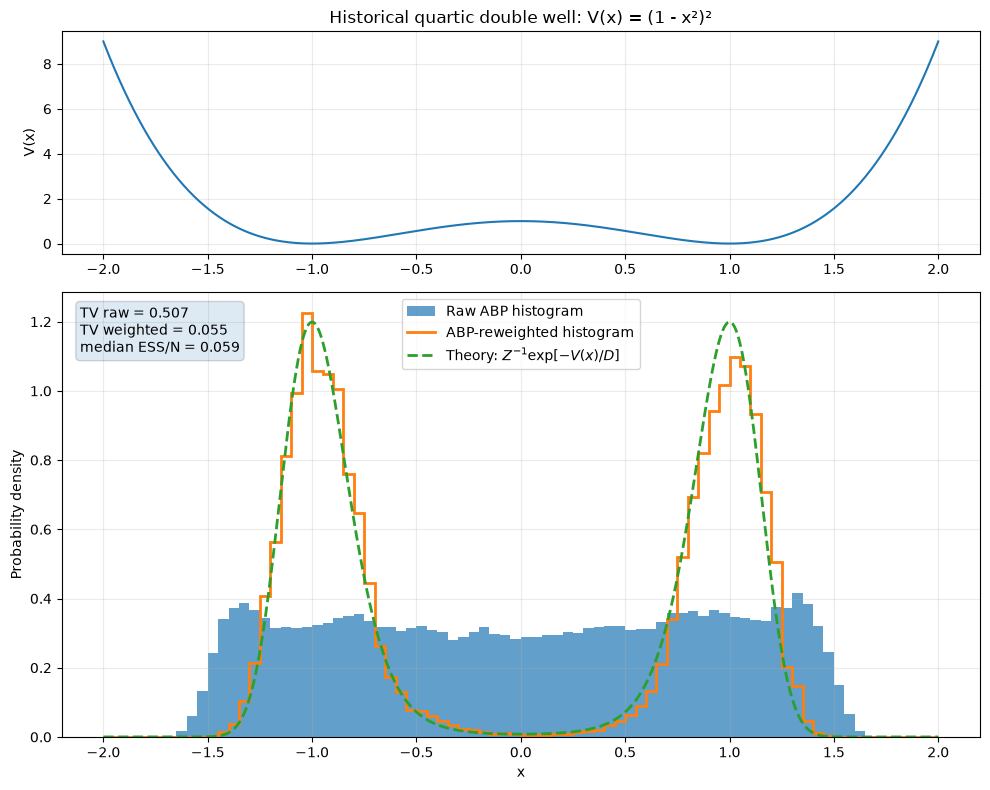

/home/administrateur/Bureau/STAGE/artifacts/notebook_05/figures/historical_double_well_raw_weighted_vs_boltzmann.png


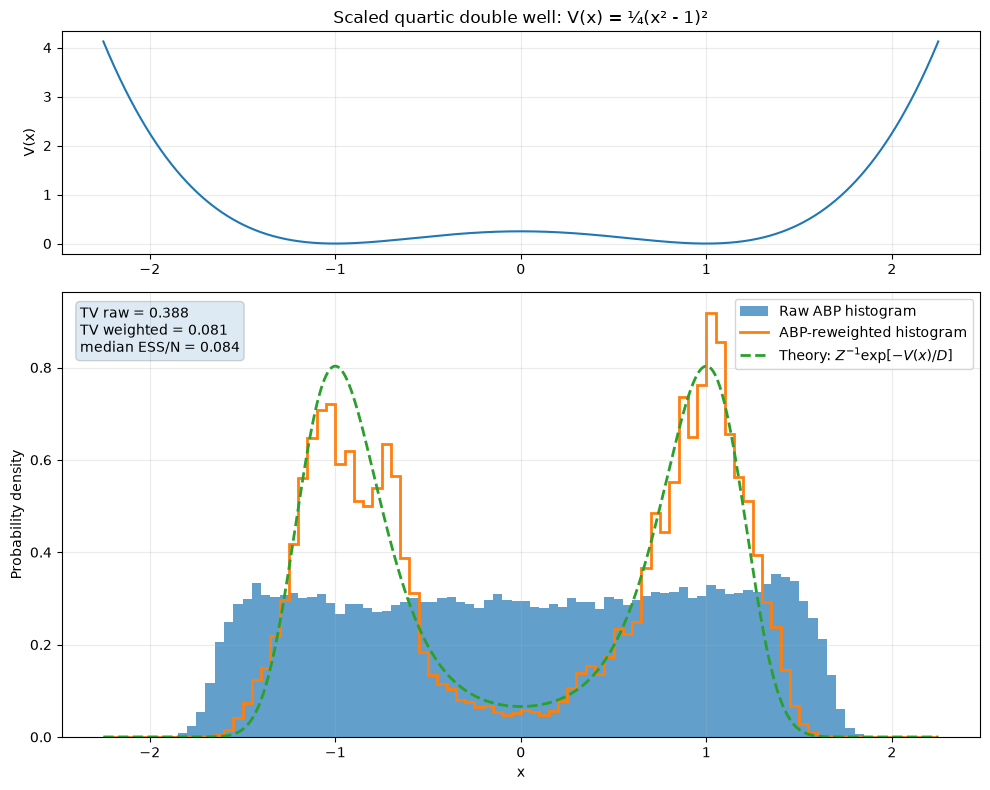

/home/administrateur/Bureau/STAGE/artifacts/notebook_05/figures/reference_double_well_raw_weighted_vs_boltzmann.png


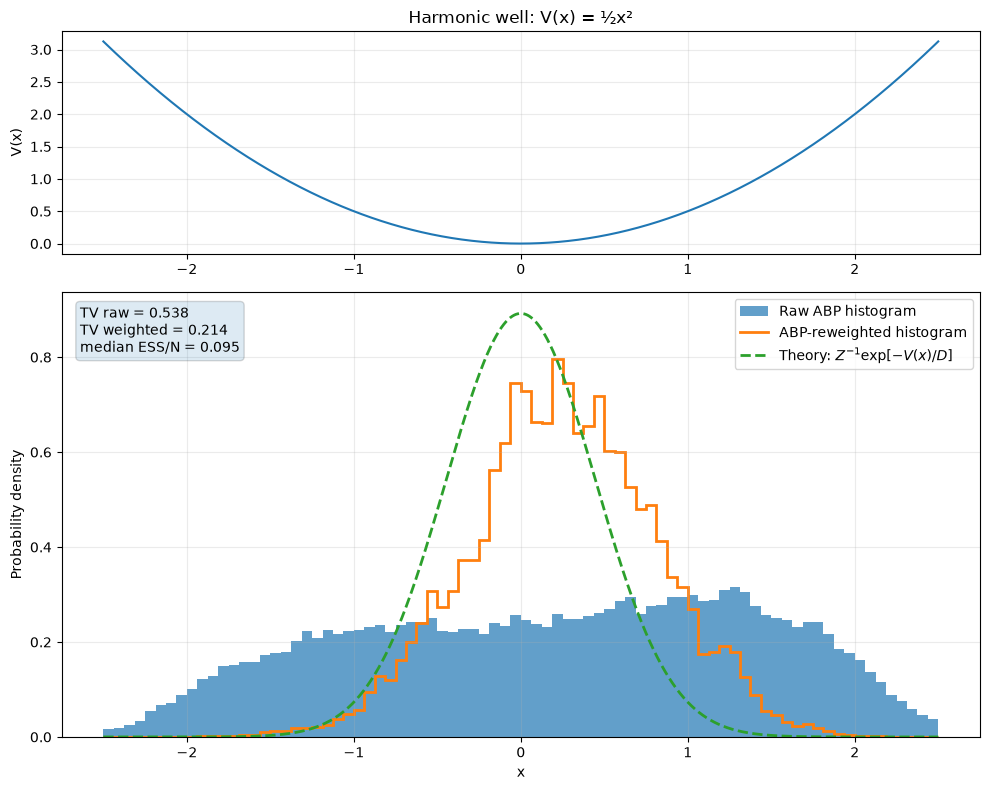

/home/administrateur/Bureau/STAGE/artifacts/notebook_05/figures/harmonic_raw_weighted_vs_boltzmann.png


In [9]:
for analysis in case_analyses.values():
    case = analysis["case"]
    edges = analysis["edges"]

    x_theory = np.linspace(*case.domain, 2_000)
    density_theory = theoretical_density_1d(
        case.potential,
        x_theory,
        case.diffusion,
    )
    _, raw_density = normalize_histogram_counts(analysis["raw_mass"], edges)
    _, weighted_density = normalize_histogram_counts(
        analysis["weighted_mass"],
        edges,
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 8),
        gridspec_kw={"height_ratios": [1, 2]},
    )

    potential_values = np.array(
        [case.potential.potential_at(np.array([value])) for value in x_theory]
    )
    axes[0].plot(x_theory, potential_values)
    axes[0].set(ylabel="V(x)", title=f"{case.label}: {case.formula}")
    axes[0].grid(alpha=0.25)

    axes[1].stairs(
        raw_density,
        edges,
        label="Raw ABP histogram",
        alpha=0.70,
        fill=True,
    )
    axes[1].stairs(
        weighted_density,
        edges,
        label="ABP-reweighted histogram",
        linewidth=2.0,
    )
    axes[1].plot(
        x_theory,
        density_theory,
        linestyle="--",
        linewidth=2.0,
        label=r"Theory: $Z^{-1}\exp[-V(x)/D]$",
    )
    axes[1].set(xlabel="x", ylabel="Probability density")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    row = summary.loc[case.key]
    axes[1].text(
        0.02,
        0.97,
        (
            f"TV raw = {row.raw_tv:.3f}\n"
            f"TV weighted = {row.weighted_tv:.3f}\n"
            f"median ESS/N = {row.median_ess_fraction:.3f}"
        ),
        transform=axes[1].transAxes,
        va="top",
        bbox={"boxstyle": "round", "alpha": 0.15},
    )

    fig.tight_layout()
    output = FIGURE_DIR / f"{case.key}_raw_weighted_vs_boltzmann.png"
    fig.savefig(output, dpi=220, bbox_inches="tight")
    plt.show()
    print(output)

## Dependence on the initial position

A pooled histogram can hide a poorly equilibrated trajectory. The following figures show the independently normalized reweighted distribution obtained from every initial position. Curves should collapse onto the same Boltzmann density once burn-in and run length are adequate.

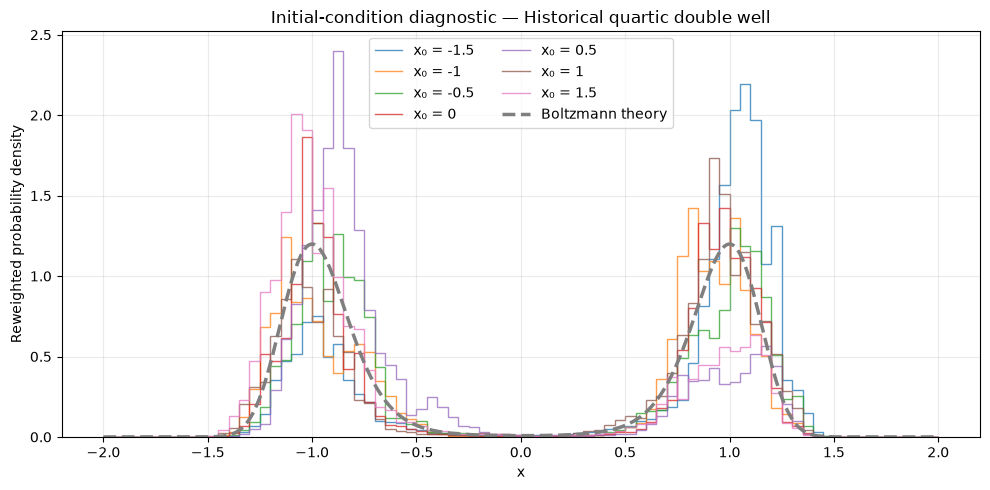

/home/administrateur/Bureau/STAGE/artifacts/notebook_05/figures/historical_double_well_initial_position_diagnostic.png


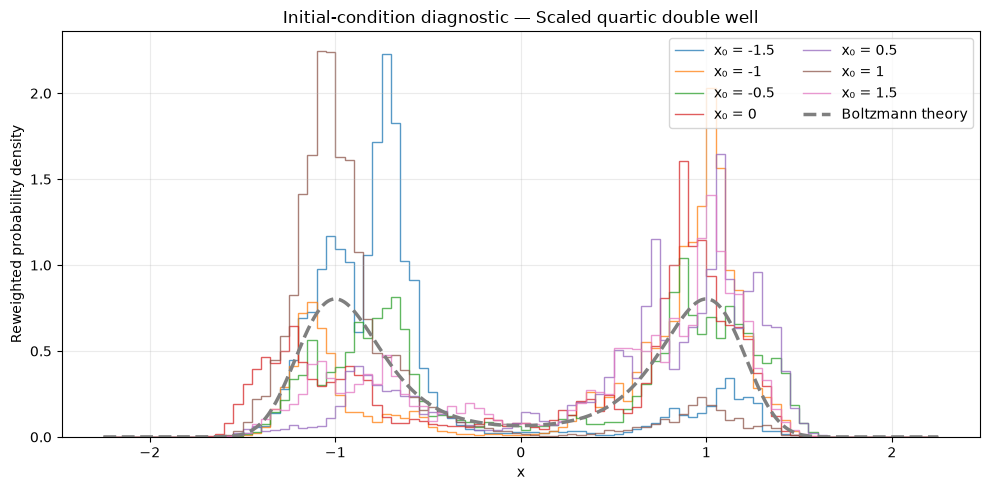

/home/administrateur/Bureau/STAGE/artifacts/notebook_05/figures/reference_double_well_initial_position_diagnostic.png


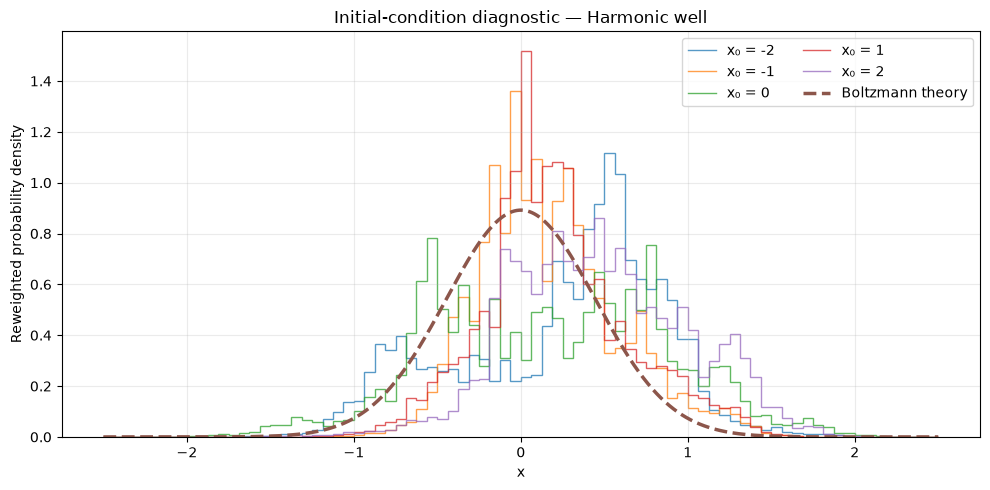

/home/administrateur/Bureau/STAGE/artifacts/notebook_05/figures/harmonic_initial_position_diagnostic.png


In [10]:
for analysis in case_analyses.values():
    case = analysis["case"]
    edges = analysis["edges"]
    x_theory = np.linspace(*case.domain, 2_000)
    density_theory = theoretical_density_1d(
        case.potential,
        x_theory,
        case.diffusion,
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    for initial_position, mass in analysis["by_initial_position"].items():
        _, density = normalize_histogram_counts(mass, edges)
        ax.stairs(
            density,
            edges,
            label=f"x₀ = {initial_position:g}",
            alpha=0.75,
        )
    ax.plot(
        x_theory,
        density_theory,
        linestyle="--",
        linewidth=2.5,
        label="Boltzmann theory",
    )
    ax.set(
        title=f"Initial-condition diagnostic — {case.label}",
        xlabel="x",
        ylabel="Reweighted probability density",
    )
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    fig.tight_layout()

    output = FIGURE_DIR / f"{case.key}_initial_position_diagnostic.png"
    fig.savefig(output, dpi=220, bbox_inches="tight")
    plt.show()
    print(output)

## Trajectory-level diagnostics

The following table should be inspected before accepting or rejecting the exponential law:

- a small `ess_fraction` means that only a few very large weights dominate the estimator;
- a large `window_tv` means the first and second halves of the retained trajectory disagree;
- a non-negligible `outside_fraction` means the histogram domain is truncating simulated positions.

In [11]:
trajectory_diagnostics_df.sort_values(
    ["case_key", "initial_position", "replicate"]
).reset_index(drop=True)

,case_key,initial_position,replicate,raw_mass,weighted_mass,ess,ess_fraction,outside_fraction,window_tv,n_retained
0,harmonic,-2.0,0,"[0.0030308132682269743, 0.002862434753325476, ...","[9.24990313820952e-07, 1.6574159344529267e-06,...",679.109364,0.113166,0.010332,0.413192,6001
1,harmonic,-2.0,1,"[0.0, 0.0, 0.0, 0.0, 0.0008369601606963508, 0....","[0.0, 0.0, 0.0, 0.0, 2.8163474379821258e-08, 1...",545.606330,0.090919,0.004499,0.610872,6001
2,harmonic,-1.0,0,"[0.0, 0.0, 0.00016672224074691563, 0.001667222...","[0.0, 0.0, 2.8494202821076718e-09, 3.298911704...",598.815864,0.099786,0.000500,0.337902,6001
3,harmonic,-1.0,1,"[0.0, 0.0, 0.0, 0.00016663889351774705, 0.0001...","[0.0, 0.0, 0.0, 1.529103619541291e-09, 1.78151...",339.242561,0.056531,0.000000,0.367395,6001
4,harmonic,0.0,0,"[0.0, 0.0006711409395973154, 0.000335570469798...","[0.0, 8.221308897094211e-08, 4.636138188538979...",814.996355,0.135810,0.006832,0.499672,6001
5,harmonic,0.0,1,"[0.005215343203230148, 0.005720053835800807, 0...","[2.6463860902393964e-06, 3.890610843770691e-06...",684.624567,0.114085,0.009498,0.390038,6001
6,harmonic,1.0,0,"[0.0008338892595063375, 0.0021681120747164776,...","[3.743870180613908e-08, 1.2101110068055224e-07...",488.919049,0.081473,0.000833,0.525468,6001
7,harmonic,1.0,1,"[0.0, 0.0, 0.00016702856188408218, 0.0, 0.0008...","[0.0, 0.0, 2.6317796652065448e-09, 0.0, 1.8187...",465.524640,0.077575,0.002333,0.213890,6001
8,harmonic,2.0,0,"[0.0008344459279038719, 0.0005006675567423231,...","[9.023177085690435e-08, 7.475824785110925e-08,...",495.362848,0.082547,0.001500,0.392747,6001
9,harmonic,2.0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.000504540867810292...","[0.0, 0.0, 0.0, 0.0, 0.0, 3.952809061688126e-0...",622.464898,0.103727,0.009165,0.539589,6001


## Interpretation

The exponential law is numerically supported for a potential only when all of the following observations are compatible:

1. reweighting reduces the discrepancy relative to the raw biased histogram;
2. the weighted histogram follows the locations and relative masses of the theoretical modes;
3. results obtained from different initial positions collapse onto the same density;
4. the late-window discrepancy is small enough to indicate stabilization;
5. the effective sample size is not pathologically low;
6. the selected domain does not truncate appreciable probability mass.

The thresholds below are diagnostics rather than formal hypothesis-test levels. A `full` run should be used for report conclusions; `smoke` mode only checks that the complete pipeline works and that the qualitative behavior is plausible.

In [12]:
def diagnostic_conclusion(row: pd.Series) -> str:
    if row.max_outside_fraction > 0.01:
        return "extend histogram domain"
    if row.median_ess_fraction < 0.02:
        return "reweighting dominated by few samples"
    if row.median_window_tv > 0.15:
        return "trajectory not yet stable"
    if row.weighted_tv < 0.15 and row.weighted_improves_tv and row.weighted_improves_js:
        return "consistent with exp(-V/D)"
    if row.weighted_improves_tv and row.weighted_improves_js:
        return "reweighting improves agreement; longer run needed"
    return "exponential law not validated by this run"


report = summary.copy()
report["diagnostic_conclusion"] = report.apply(diagnostic_conclusion, axis=1)
report

,raw_tv,weighted_tv,raw_hellinger,weighted_hellinger,raw_js,weighted_js,raw_cdf_sup,weighted_cdf_sup,median_ess_fraction,median_window_tv,max_outside_fraction,weighted_improves_tv,weighted_improves_js,diagnostic_conclusion
case,,,,,,,,,,,,,,
historical_double_well,0.507180,0.055206,0.456355,0.052694,0.187068,0.002768,0.176576,0.026400,0.059214,0.448548,0.000000,True,True,trajectory not yet stable
reference_double_well,0.387822,0.081448,0.348414,0.080415,0.110831,0.006412,0.112056,0.038062,0.084449,0.546250,0.000000,True,True,trajectory not yet stable
harmonic,0.537838,0.214017,0.507876,0.209459,0.218184,0.041849,0.329004,0.209996,0.095353,0.402969,0.010332,True,True,extend histogram domain


## Final reproducibility record

Keep this cell in the committed notebook output. It records the exact execution mode and the principal numerical settings used to produce the figures and tables.

In [13]:
reproducibility_record = {
    "repository_revision": "3d29c8a",
    "run_mode": RUN_MODE,
    "base_seed": BASE_SEED,
    "reuse_cache": REUSE_CACHE,
    "n_jobs": N_JOBS,
    "smoke_replicates": SMOKE_REPLICATES,
    "full_replicates": FULL_REPLICATES,
    "burn_in_fraction": BURN_IN_FRACTION,
    "thinning_stride": THINNING_STRIDE,
    "number_of_trajectories": len(runs),
    "cache_directory": str(CACHE_DIR),
    "figure_directory": str(FIGURE_DIR),
    "case_signatures": {
        key: simulation_signature(case)
        for key, case in POTENTIAL_CASES.items()
    },
}
reproducibility_record

{'repository_revision': '3d29c8a',
 'run_mode': 'full',
 'base_seed': 2026,
 'reuse_cache': True,
 'n_jobs': -1,
 'smoke_replicates': 1,
 'full_replicates': 2,
 'burn_in_fraction': 0.2,
 'thinning_stride': 10,
 'number_of_trajectories': 38,
 'cache_directory': '/home/administrateur/Bureau/STAGE/artifacts/notebook_05/results',
 'figure_directory': '/home/administrateur/Bureau/STAGE/artifacts/notebook_05/figures',
 'case_signatures': {'historical_double_well': 'd9bfd2479e',
  'reference_double_well': '071436ec01',
  'harmonic': '35726d09d3'}}